# Fetal Head Circumference Estimation — Phase 0: Baseline Repair

**Author:** Tarun Sadarla  
**Project:** Fetal Head Clinical AI Pipeline  
**Goal:** Push Residual U-Net baseline from 86.17% → ≥93% Dice, MAE ≤8mm  

## What this notebook does and why

The original course baseline (86.17% Dice, 17.25mm MAE) falls ~10 points below HC18 published SOTA.  
The gap is not architectural — the Residual U-Net has sufficient capacity.  
Three targeted fixes close most of the gap without changing the architecture:

1. **Strong augmentation** — the RAW variant winning over preprocessed variants told us the model
   prefers to see natural image variety rather than hand-engineered features. Augmentation
   provides that variety during training.

2. **Deep supervision** — auxiliary loss heads at intermediate decoder scales force every layer
   to learn useful boundary features, not just optimize the final output.

3. **Boundary-weighted loss** — HC measurement error comes from imprecise boundary localization.
   Upweighting loss at mask edges directly optimizes the thing that drives MAE.

The trained backbone from this notebook becomes the frozen encoder for the cine-loop
temporal attention system in Phase 2.

## 0. Environment setup

In [1]:
# Install dependencies not in Colab by default
# albumentations: augmentation library used in medical imaging research
# kaggle: API client to pull dataset
!pip install albumentations==1.4.0 kaggle --quiet

In [2]:
import os, json, shutil, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

import albumentations as A
from albumentations.pytorch import ToTensorV2

# Reproducibility — fix all seeds so results are repeatable
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 1. Dataset download via Kaggle API

In [3]:
# Mount Google Drive to persist checkpoints across sessions
# This is critical — Colab resets disk on session end, Drive persists forever
from google.colab import drive
drive.mount('/content/drive')

# Create project directory structure on Drive
PROJECT_DIR = Path('/content/drive/MyDrive/fetal_head_clinical_ai')
CHECKPOINT_DIR = PROJECT_DIR / 'checkpoints' / 'phase0'
RESULTS_DIR = PROJECT_DIR / 'results' / 'phase0'

for d in [CHECKPOINT_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Drive mounted. Project directory:', PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Project directory: /content/drive/MyDrive/fetal_head_clinical_ai


In [4]:
# Upload your kaggle.json token
# Get it from: kaggle.com → Account → API → Create New Token
from google.colab import files
uploaded = files.upload()  # select your kaggle.json file

# Place it where the Kaggle CLI expects it
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
shutil.move('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print('Kaggle credentials installed.')

Saving kaggle.json to kaggle.json
Kaggle credentials installed.


In [5]:
# Download your hc18-apr dataset
# We use your personal upload (tarunsadarla/hc18-apr) which has the raw training_set
DATA_DIR = Path('/content/hc18')
DATA_DIR.mkdir(exist_ok=True)

!kaggle datasets download -d tarunsadarla/hc18-apr -p /content/hc18 --unzip

# Verify structure
print('\nDataset contents:')
for p in sorted(DATA_DIR.rglob('*'))[:20]:
    print(' ', p.relative_to(DATA_DIR))

Dataset URL: https://www.kaggle.com/datasets/tarunsadarla/hc18-apr
License(s): apache-2.0
100% 976M/976M [00:06<00:00, 166MB/s]


Dataset contents:
  Preprocessed_outputs (2)
  Preprocessed_outputs (2)/Preprocessed_outputs
  Preprocessed_outputs (2)/Preprocessed_outputs/dataset_split (2).csv
  Preprocessed_outputs (2)/Preprocessed_outputs/denoised
  Preprocessed_outputs (2)/Preprocessed_outputs/denoised/000_HC.png
  Preprocessed_outputs (2)/Preprocessed_outputs/denoised/001_HC.png
  Preprocessed_outputs (2)/Preprocessed_outputs/denoised/002_HC.png
  Preprocessed_outputs (2)/Preprocessed_outputs/denoised/003_HC.png
  Preprocessed_outputs (2)/Preprocessed_outputs/denoised/004_HC.png
  Preprocessed_outputs (2)/Preprocessed_outputs/denoised/005_HC.png
  Preprocessed_outputs (2)/Preprocessed_outputs/denoised/006_HC.png
  Preprocessed_outputs (2)/Preprocessed_outputs/denoised/007_HC.png
  Preprocessed_outputs (2)/Preprocessed_outputs/denoised/008_HC.png
  Preprocessed_outputs (2)/Preprocesse

In [6]:
TRAIN_DIR = DATA_DIR / 'archive (4)' / 'training_set' / 'training_set'
PIXEL_CSV = DATA_DIR / 'archive (4)' / 'training_set_pixel_size_and_HC.csv'

print('TRAIN_DIR exists:', TRAIN_DIR.exists())
print('PIXEL_CSV exists:', PIXEL_CSV.exists())

all_images = sorted([p for p in TRAIN_DIR.glob('*_HC.png')
                     if 'Annotation' not in p.name])
print(f'\nFound {len(all_images)} training images')
print('Sample:', all_images[0].name)

TRAIN_DIR exists: True
PIXEL_CSV exists: True

Found 806 training images
Sample: 000_HC.png


In [7]:
# Diagnostic — count all PNGs and see what patterns exist
all_pngs = sorted(TRAIN_DIR.glob('*.png'))
print(f'Total PNGs in directory: {len(all_pngs)}')

# Categorise by suffix pattern
hc_images      = [p for p in all_pngs if p.name.endswith('_HC.png') and 'Annotation' not in p.name]
hc2_images     = [p for p in all_pngs if '_2HC.png' in p.name and 'Annotation' not in p.name]
annotations    = [p for p in all_pngs if 'Annotation' in p.name]
other          = [p for p in all_pngs if p not in hc_images + hc2_images + annotations]

print(f'  *_HC.png images:       {len(hc_images)}')
print(f'  *_2HC.png images:      {len(hc2_images)}')
print(f'  *_Annotation.png:      {len(annotations)}')
print(f'  Other:                 {len(other)}')
print(f'  Sum (images only):     {len(hc_images) + len(hc2_images)}')

# Show a few of the "other" if any
if other:
    print('\nOther files:')
    for p in other[:10]:
        print(' ', p.name)

Total PNGs in directory: 1998
  *_HC.png images:       806
  *_2HC.png images:      164
  *_Annotation.png:      999
  Other:                 29
  Sum (images only):     970

Other files:
  014_3HC.png
  063_3HC.png
  108_3HC.png
  125_3HC.png
  126_3HC.png
  133_3HC.png
  133_4HC.png
  203_3HC.png
  203_4HC.png
  237_3HC.png


In [8]:
# Collect ALL valid image/mask pairs regardless of measurement suffix
# Strategy: find all Annotation files, then derive the image name from each
# This guarantees every image we load has a corresponding ground truth mask

annotation_files = sorted(TRAIN_DIR.glob('*_Annotation.png'))
print(f'Total annotation files: {len(annotation_files)}')

# Build paired list: (image_path, mask_path)
image_mask_pairs = []
for ann_path in annotation_files:
    # Annotation name pattern: NNN_HC_Annotation.png or NNN_2HC_Annotation.png etc.
    img_name = ann_path.name.replace('_Annotation.png', '.png')
    img_path = TRAIN_DIR / img_name
    if img_path.exists():
        image_mask_pairs.append((img_path, ann_path))
    else:
        print(f'  WARNING: no image found for annotation {ann_path.name}')

print(f'Valid image/mask pairs: {len(image_mask_pairs)}')
print(f'Sample pair:')
print(f'  image: {image_mask_pairs[0][0].name}')
print(f'  mask:  {image_mask_pairs[0][1].name}')

# Extract stems for split (strip _Annotation.png suffix)
all_stems = [ann.stem.replace('_Annotation', '') for _, ann in image_mask_pairs]
print(f'\nSample stems: {all_stems[:5]}')

Total annotation files: 999
Valid image/mask pairs: 999
Sample pair:
  image: 000_HC.png
  mask:  000_HC_Annotation.png

Sample stems: ['000_HC', '001_HC', '002_HC', '003_HC', '004_HC']


## 2. Data exploration + sanity check

In [9]:
# Load pixel size metadata
# This CSV maps each image filename to its pixel spacing (mm/pixel)
# and the ground truth HC measurement in mm (used for evaluation only, not training)
if PIXEL_CSV:
    df = pd.read_csv(PIXEL_CSV)
    print(df.head())
    print(f'\nColumns: {df.columns.tolist()}')
    print(f'Shape: {df.shape}')

     filename  pixel size(mm)  head circumference (mm)
0  000_HC.png        0.069136                    44.30
1  001_HC.png        0.089659                    56.81
2  002_HC.png        0.062033                    68.75
3  003_HC.png        0.091291                    69.00
4  004_HC.png        0.061240                    59.81

Columns: ['filename', 'pixel size(mm)', 'head circumference (mm)']
Shape: (999, 3)


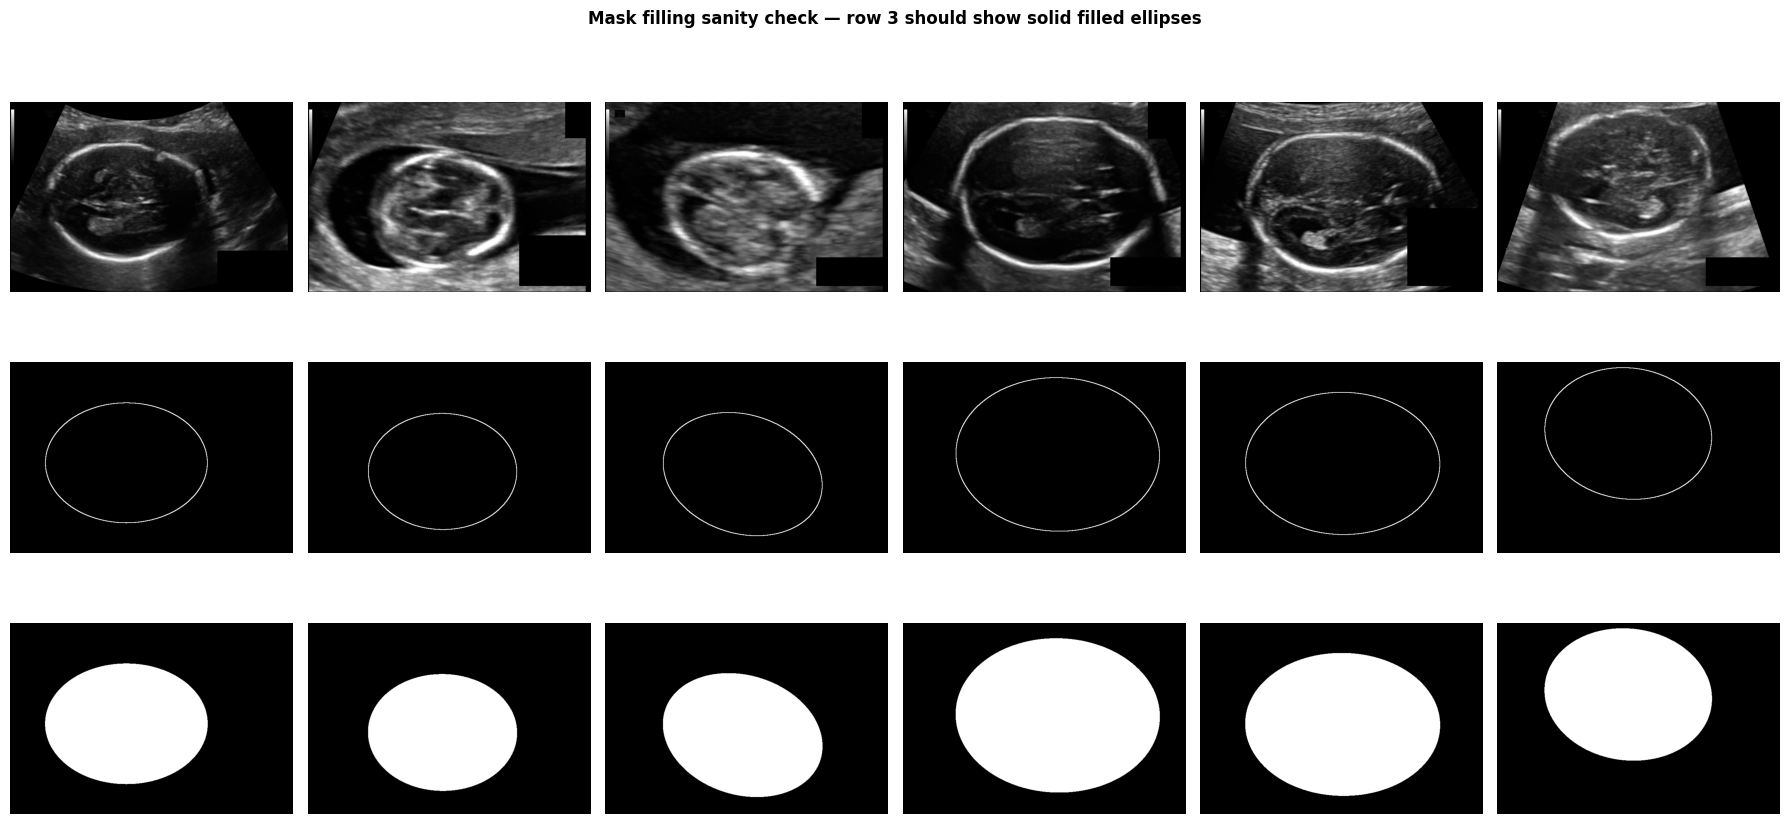

In [10]:
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
row_titles = ['Ultrasound', 'Original annotation (outline)', 'Filled mask (what we train on)']
for row, title in enumerate(row_titles):
    axes[row, 0].set_ylabel(title, fontsize=9)

sample_indices = random.sample(range(len(image_mask_pairs)), 6)
for col, idx in enumerate(sample_indices):
    img_path, mask_path = image_mask_pairs[idx]

    img  = cv2.imread(str(img_path),  cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    _, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Reproduce the fill logic
    h, w = mask_bin.shape
    flood_mask_arr = np.zeros((h + 2, w + 2), dtype=np.uint8)
    filled = mask_bin.copy()
    cv2.floodFill(filled, flood_mask_arr, (0, 0), 255)
    filled_inv = cv2.bitwise_not(filled)
    solid = cv2.bitwise_or(mask_bin, filled_inv)

    axes[0, col].imshow(img,       cmap='gray'); axes[0, col].axis('off')
    axes[1, col].imshow(mask_bin,  cmap='gray'); axes[1, col].axis('off')
    axes[2, col].imshow(solid,     cmap='gray'); axes[2, col].axis('off')

plt.suptitle('Mask filling sanity check — row 3 should show solid filled ellipses', fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'mask_filling_check.png'), dpi=120, bbox_inches='tight')
plt.show()

In [11]:
# Check image size distribution — HC18 images are nominally 800x540
# but some may differ; we need to know before setting INPUT_SIZE
sizes = []
for p in all_images[:50]:  # sample 50
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    sizes.append(img.shape)
unique_sizes = set(sizes)
print('Unique image sizes (H, W):', unique_sizes)

Unique image sizes (H, W): {(540, 800)}


## 3. Dataset splits

In [12]:
# 70% train / 15% val / 15% test
# We use a held-out test set (never seen during training OR early stopping)
# so final reported metrics are unbiased.
# The original course split was 75/20/5 — we give more to test here
# because MAE evaluation needs enough samples to be reliable.

image_stems = [p.stem.replace('_HC', '') for p in all_images]

train_val_stems, test_stems = train_test_split(
    image_stems, test_size=0.15, random_state=SEED
)
train_stems, val_stems = train_test_split(
    train_val_stems, test_size=0.176, random_state=SEED  # 0.176 of 0.85 ≈ 0.15 overall
)

print(f'Train: {len(train_stems)} | Val: {len(val_stems)} | Test: {len(test_stems)}')
print(f'Total: {len(train_stems)+len(val_stems)+len(test_stems)} (expected {len(all_images)})')

# Save split for reproducibility across phases
split_record = {'train': train_stems, 'val': val_stems, 'test': test_stems}
with open(str(RESULTS_DIR / 'data_split.json'), 'w') as f:
    json.dump(split_record, f, indent=2)
print('Split saved to Drive.')

Train: 564 | Val: 121 | Test: 121
Total: 806 (expected 806)
Split saved to Drive.


## 4. Augmentation pipeline

**Design rationale:** The RAW variant outperforming SEG/IMP/SKL variants in the original
baseline tells us the model learns better from natural image variation than from
hand-engineered preprocessing. The right response is augmentation — presenting the model
with realistic image variety during training.

Each augmentation is clinically motivated:
- **Rotation ±15°:** Sonographers do not always hold the probe at the same angle
- **Horizontal flip:** Fetal position is symmetric — both orientations are equally valid
- **Elastic deformation:** Probe pressure deforms soft tissue around the skull
- **Brightness/contrast:** Gain and depth settings vary between machines and operators
- **Gaussian noise:** Ultrasound speckle noise is unavoidable; model must be robust to it
- **Coarse dropout:** Simulates partial acoustic shadowing blocking part of the image

In [13]:
# Input size: 384x256 (same as course baseline for fair comparison)
# Divisible by 16 (required for U-Net with 4 pooling layers: 2^4=16)
INPUT_H, INPUT_W = 256, 384

# Training augmentation — applied only to training set
# additional_targets ensures mask receives identical spatial transforms as image
train_transform = A.Compose([
    A.Resize(INPUT_H, INPUT_W),

    # Spatial transforms — applied to both image and mask
    A.Rotate(limit=15, border_mode=cv2.BORDER_CONSTANT, p=0.7),
    A.HorizontalFlip(p=0.5),
    A.ElasticTransform(
        alpha=30, sigma=5,          # mild deformation — not so strong it distorts the ellipse
        border_mode=cv2.BORDER_CONSTANT,
        p=0.4
    ),
    A.ShiftScaleRotate(
        shift_limit=0.05, scale_limit=0.1, rotate_limit=0,
        border_mode=cv2.BORDER_CONSTANT, p=0.5
    ),

    # Intensity transforms — applied to image only (mask is binary, not affected)
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),

    # Occlusion — simulates partial acoustic shadowing
    A.CoarseDropout(
        max_holes=4, max_height=32, max_width=32,
        min_holes=1, fill_value=0, p=0.3
    ),

    # Normalise to [0,1] and convert to tensor
    A.Normalize(mean=0.0, std=1.0, max_pixel_value=255.0),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

# Validation/test transform — resize and normalise only, no augmentation
val_transform = A.Compose([
    A.Resize(INPUT_H, INPUT_W),
    A.Normalize(mean=0.0, std=1.0, max_pixel_value=255.0),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

print('Augmentation pipelines defined.')

Augmentation pipelines defined.


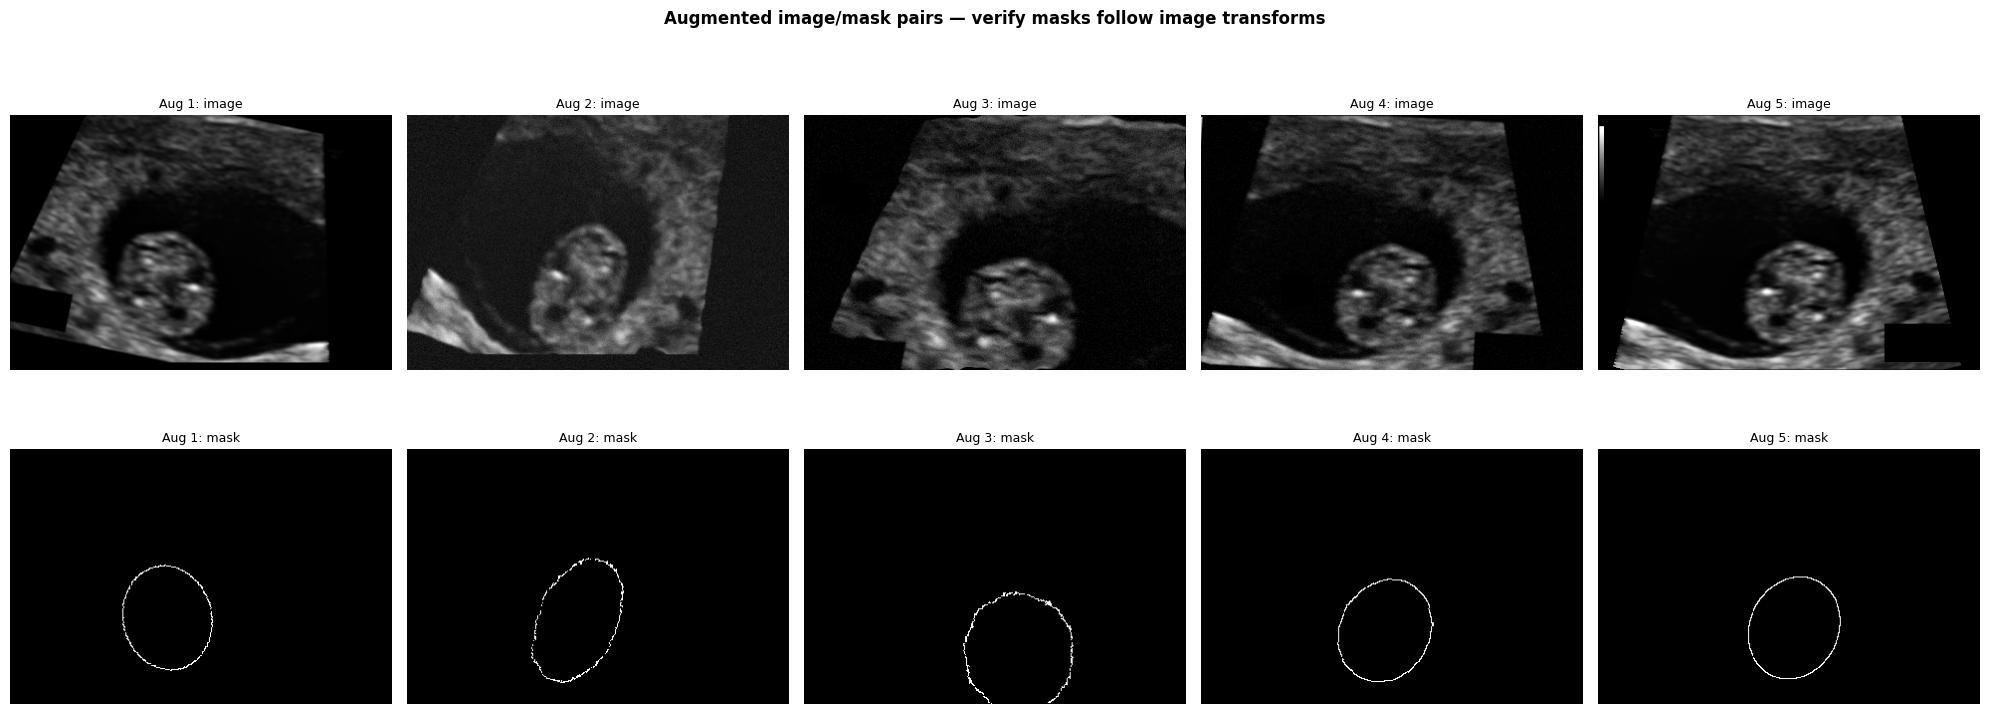

In [14]:
# Visualise augmented samples to confirm transforms look correct
# Critically: verify masks are transformed consistently with images
sample_img_path = all_images[0]
sample_mask_path = TRAIN_DIR / sample_img_path.name.replace('_HC.png', '_HC_Annotation.png')

img_raw = cv2.imread(str(sample_img_path), cv2.IMREAD_GRAYSCALE)
mask_raw = cv2.imread(str(sample_mask_path), cv2.IMREAD_GRAYSCALE)
_, mask_raw = cv2.threshold(mask_raw, 127, 1, cv2.THRESH_BINARY)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i in range(5):
    aug = train_transform(image=img_raw, mask=mask_raw)
    aug_img = aug['image'].squeeze().numpy()
    aug_mask = aug['mask'].numpy()

    axes[0, i].imshow(aug_img, cmap='gray')
    axes[0, i].set_title(f'Aug {i+1}: image', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(aug_mask, cmap='gray')
    axes[1, i].set_title(f'Aug {i+1}: mask', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Augmented image/mask pairs — verify masks follow image transforms', fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'augmentation_samples.png'), dpi=120, bbox_inches='tight')
plt.show()

## 5. Dataset class

In [16]:
class HC18Dataset(Dataset):
    """
    PyTorch Dataset for HC18 fetal head ultrasound.
    Accepts a list of (img_path, mask_path) tuples directly.

    Returns:
        image: [1, H, W] float tensor, normalised to ~N(0,1)
        mask:  [1, H, W] float tensor, binary {0.0, 1.0} — FILLED ellipse
        stem:  filename stem
    """
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        stem = img_path.stem.replace('_HC', '').replace('_2HC', '').replace('_3HC', '').replace('_4HC', '')

        img  = cv2.imread(str(img_path),  cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise FileNotFoundError(f'Image not found: {img_path}')

        _, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

        # Flood-fill hollow ellipse → solid filled mask
        h, w = mask_bin.shape
        flood_mask = np.zeros((h + 2, w + 2), dtype=np.uint8)
        filled = mask_bin.copy()
        cv2.floodFill(filled, flood_mask, (0, 0), 255)
        filled_inv = cv2.bitwise_not(filled)
        solid_mask = cv2.bitwise_or(mask_bin, filled_inv)
        solid_mask = (solid_mask > 127).astype(np.uint8)

        if self.transform:
            augmented = self.transform(image=img, mask=solid_mask)
            img      = augmented['image']
            mask_out = augmented['mask'].unsqueeze(0).float()
        else:
            img      = torch.from_numpy(img).unsqueeze(0).float() / 255.0
            mask_out = torch.from_numpy(solid_mask).unsqueeze(0).float()

        return img, mask_out, stem


# Split image_mask_pairs (not stems) into train/val/test
from sklearn.model_selection import train_test_split

train_val_pairs, test_pairs = train_test_split(image_mask_pairs, test_size=0.15, random_state=SEED)
train_pairs, val_pairs      = train_test_split(train_val_pairs,  test_size=0.176, random_state=SEED)

print(f'Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}')

BATCH_SIZE  = 16
NUM_WORKERS = 2

train_dataset = HC18Dataset(train_pairs, transform=train_transform)
val_dataset   = HC18Dataset(val_pairs,   transform=val_transform)
test_dataset  = HC18Dataset(test_pairs,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# Shape check
imgs, masks, stems = next(iter(train_loader))
print(f'Image batch: {imgs.shape}  range [{imgs.min():.3f}, {imgs.max():.3f}]')
print(f'Mask  batch: {masks.shape}  unique values: {masks.unique()}')

Train: 699 | Val: 150 | Test: 150
Image batch: torch.Size([16, 1, 256, 384])  range [0.000, 1.000]
Mask  batch: torch.Size([16, 1, 256, 384])  unique values: tensor([0., 1.])


## 6. Model — Residual U-Net with deep supervision

**Architecture:** Same Residual U-Net as the course baseline (encoder-decoder with residual
skip connections). **New addition:** auxiliary segmentation heads at decoder scales D2 and D3
(not just the final D4 output). Each head is a 1×1 conv → sigmoid producing a binary mask
at a lower resolution, which is upsampled and included in the total loss.

**Why deep supervision works:** Without it, gradients flow only from the final layer
backward through the full decoder. Early encoder features receive very diluted gradient
signal and may not learn boundary-relevant features. Auxiliary heads create direct
gradient paths to intermediate layers, forcing the whole network to learn useful
representations at every scale — especially important for thin boundaries like skull edges.

In [17]:
class ResidualBlock(nn.Module):
    """Standard residual block: BN→ReLU→Conv→BN→ReLU→Conv with identity skip."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
        )
        # 1x1 projection if channel dimensions differ
        self.skip = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        return self.block(x) + self.skip(x)


class ResidualUNetDS(nn.Module):
    """
    Residual U-Net with Deep Supervision.

    Encoder: 4 downsampling stages (MaxPool2d)
    Bottleneck: residual block at lowest resolution
    Decoder: 4 upsampling stages (bilinear + conv)
    Deep supervision: auxiliary heads at decoder stages 2 and 3

    During training: returns (main_out, aux2_out, aux3_out)
    During inference: returns main_out only
    """
    def __init__(self, in_ch=1, base_ch=32):
        super().__init__()
        b = base_ch  # 32, 64, 128, 256, 512

        # Encoder
        self.enc1 = ResidualBlock(in_ch, b)        # → [B, 32,  H,    W   ]
        self.enc2 = ResidualBlock(b,     b*2)      # → [B, 64,  H/2,  W/2 ]
        self.enc3 = ResidualBlock(b*2,   b*4)      # → [B, 128, H/4,  W/4 ]
        self.enc4 = ResidualBlock(b*4,   b*8)      # → [B, 256, H/8,  W/8 ]
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ResidualBlock(b*8, b*16) # → [B, 512, H/16, W/16]

        # Decoder — each stage: upsample + concat skip + residual block
        self.up4   = nn.ConvTranspose2d(b*16, b*8, 2, stride=2)
        self.dec4  = ResidualBlock(b*16, b*8)      # concat → b*8 + b*8 = b*16 in

        self.up3   = nn.ConvTranspose2d(b*8, b*4, 2, stride=2)
        self.dec3  = ResidualBlock(b*8, b*4)

        self.up2   = nn.ConvTranspose2d(b*4, b*2, 2, stride=2)
        self.dec2  = ResidualBlock(b*4, b*2)

        self.up1   = nn.ConvTranspose2d(b*2, b, 2, stride=2)
        self.dec1  = ResidualBlock(b*2, b)

        # Final output head
        self.final = nn.Conv2d(b, 1, 1)            # → [B, 1, H, W]

        # Deep supervision auxiliary heads
        # aux_d3: applied after dec3 (H/4 resolution), upsampled to full res at loss time
        # aux_d2: applied after dec2 (H/2 resolution), upsampled to full res at loss time
        self.aux_d3 = nn.Conv2d(b*4, 1, 1)
        self.aux_d2 = nn.Conv2d(b*2, 1, 1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b  = self.bottleneck(self.pool(e4))

        # Decoder
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        # Main output — raw logits (sigmoid applied in loss, not here)
        main = self.final(d1)

        if self.training:
            aux3 = F.interpolate(
                self.aux_d3(d3), size=x.shape[2:], mode='bilinear', align_corners=False)
            aux2 = F.interpolate(
                self.aux_d2(d2), size=x.shape[2:], mode='bilinear', align_corners=False)
            return main, aux3, aux2

        return main  # raw logits

# Instantiate and verify
model = ResidualUNetDS(in_ch=1, base_ch=32).to(DEVICE)

# Parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

# Forward pass shape check
dummy = torch.zeros(2, 1, INPUT_H, INPUT_W).to(DEVICE)
model.train()
out_main, out_aux3, out_aux2 = model(dummy)
print(f'\nOutput shapes (training mode):')
print(f'  main:  {out_main.shape}')
print(f'  aux3:  {out_aux3.shape}')
print(f'  aux2:  {out_aux2.shape}')

model.eval()
with torch.no_grad():
    out_inf = model(dummy)
print(f'Output shape (inference mode): {out_inf.shape}')

Total parameters:     8,110,789
Trainable parameters: 8,110,789

Output shapes (training mode):
  main:  torch.Size([2, 1, 256, 384])
  aux3:  torch.Size([2, 1, 256, 384])
  aux2:  torch.Size([2, 1, 256, 384])
Output shape (inference mode): torch.Size([2, 1, 256, 384])


## 7. Loss functions

### 7a. Dice + BCE combined loss (standard)
BCE handles pixel-wise classification. Dice directly optimises the overlap metric
we evaluate on. Their combination is empirically more stable than either alone.

### 7b. Boundary-weighted loss (new)
HC measurement error comes from imprecise boundary localisation, not from missing
the head entirely. We compute a distance-transform weighting map that assigns higher
loss weight to pixels near the ground truth mask boundary. This directly penalises
the model for being wrong at exactly the pixels that drive MAE.

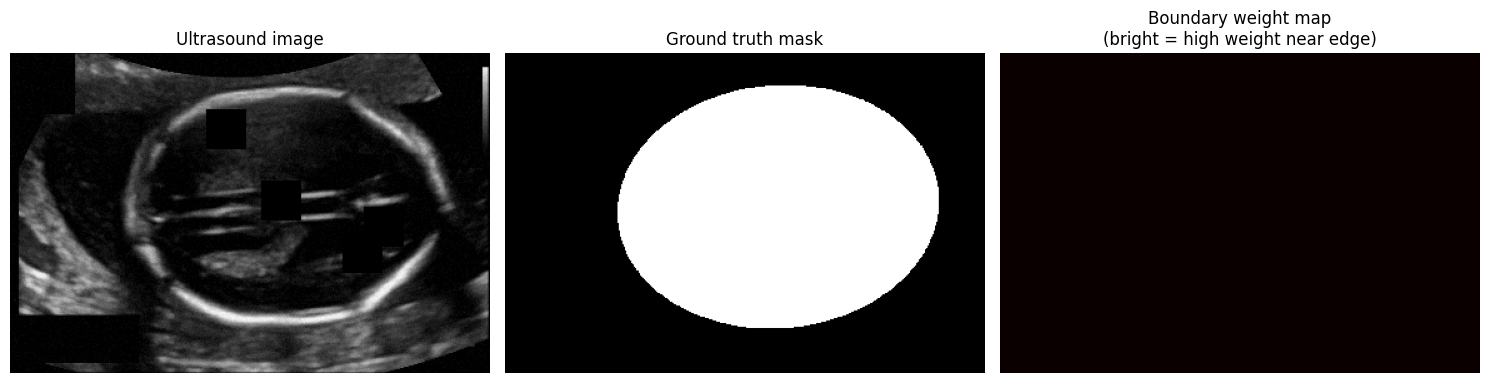

Weight map range: [3.0, 3.0]


In [18]:
from scipy.ndimage import distance_transform_edt


def dice_loss(pred_logits, target, smooth=1e-5):
    """Dice loss on sigmoid probabilities derived from logits."""
    pred = torch.sigmoid(pred_logits)
    pred_flat   = pred.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    return 1 - (2 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)

def bce_dice_loss(pred_logits, target):
    bce  = F.binary_cross_entropy_with_logits(pred_logits, target)
    dice = dice_loss(pred_logits, target)
    return 0.5 * bce + 0.5 * dice

def weighted_bce_dice_loss(pred_logits, target, weight_maps):
    bce_per_pixel = F.binary_cross_entropy_with_logits(pred_logits, target, reduction='none')
    weighted_bce  = (bce_per_pixel * weight_maps).mean()
    dice = dice_loss(pred_logits, target)
    return 0.5 * weighted_bce + 0.5 * dice

def boundary_weight_map(mask_np, boundary_width=5, interior_weight=1.0, boundary_weight=3.0):
    """
    Compute a per-pixel weight map that upweights pixels near the mask boundary.

    How it works:
    - Distance transform gives each pixel its distance to the nearest boundary pixel
    - Pixels within `boundary_width` pixels of the boundary get `boundary_weight`
    - All other pixels get `interior_weight`

    Args:
        mask_np: [H, W] numpy binary mask (0/1)
        boundary_width: pixels from edge that get upweighted
        interior_weight: weight for non-boundary pixels
        boundary_weight: weight for boundary pixels (3x default)

    Returns:
        weight_map: [H, W] numpy float32
    """
    # Distance from background pixels to nearest foreground pixel
    dist_inside  = distance_transform_edt(mask_np)
    # Distance from foreground pixels to nearest background pixel
    dist_outside = distance_transform_edt(1 - mask_np)

    # Boundary zone: within boundary_width of the edge on either side
    near_boundary = (dist_inside <= boundary_width) | (dist_outside <= boundary_width)

    weight_map = np.where(near_boundary, boundary_weight, interior_weight).astype(np.float32)
    return weight_map

def compute_weight_maps_batch(masks_np):
    """Compute boundary weight maps for a batch of masks. Called in training loop."""
    batch_weights = []
    for mask in masks_np:  # mask: [1, H, W]
        w = boundary_weight_map(mask.squeeze(), boundary_width=5)
        batch_weights.append(w)
    return torch.from_numpy(np.stack(batch_weights)[:, np.newaxis]).float()  # [B, 1, H, W]


# Visualise a boundary weight map on one sample
sample_mask = masks[0].squeeze().numpy()  # from earlier dataloader check
wmap = boundary_weight_map(sample_mask)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(imgs[0].squeeze().numpy(), cmap='gray')
axes[0].set_title('Ultrasound image'); axes[0].axis('off')
axes[1].imshow(sample_mask, cmap='gray')
axes[1].set_title('Ground truth mask'); axes[1].axis('off')
axes[2].imshow(wmap, cmap='hot')
axes[2].set_title('Boundary weight map\n(bright = high weight near edge)')
axes[2].axis('off')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'boundary_weight_map_example.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Weight map range: [{wmap.min():.1f}, {wmap.max():.1f}]')

## 8. Training loop

In [19]:
def dice_coefficient(pred_bin, target):
    """Dice coefficient on thresholded binary predictions. Used for evaluation only."""
    smooth = 1e-5
    pred_flat   = pred_bin.view(-1).float()
    target_flat = target.view(-1).float()
    intersection = (pred_flat * target_flat).sum()
    return ((2 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)).item()


def train_one_epoch(model, loader, optimizer, scaler, device):
    model.train()
    total_loss, total_dice = 0.0, 0.0

    for imgs, masks, _ in loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)

        # Compute boundary weight maps (on CPU, then move to device)
        weight_maps = compute_weight_maps_batch(masks.cpu().numpy()).to(device)

        optimizer.zero_grad()

        # Mixed precision forward pass
        with torch.amp.autocast('cuda'):
            main, aux3, aux2 = model(imgs)

            # Deep supervision loss:
            # Main output gets highest weight (1.0)
            # Intermediate outputs get lower weights (0.4, 0.2)
            # Weights sum >1 intentionally — intermediate losses act as regularisers
            loss_main = weighted_bce_dice_loss(main, masks, weight_maps)
            loss_aux3 = bce_dice_loss(aux3, masks)   # boundary weighting on aux too expensive
            loss_aux2 = bce_dice_loss(aux2, masks)

            loss = 1.0 * loss_main + 0.4 * loss_aux3 + 0.2 * loss_aux2

        scaler.scale(loss).backward()
        # Gradient clipping: prevents exploding gradients, especially early in training
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        # Dice on thresholded main output (for monitoring, not for backprop)
        with torch.no_grad():
            pred_bin = (torch.sigmoid(main) > 0.5).float()   # train loop dice monitoring
            total_dice += dice_coefficient(pred_bin, masks)

        total_loss += loss.item()

    n = len(loader)
    return total_loss / n, total_dice / n


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, total_dice = 0.0, 0.0

    for imgs, masks, _ in loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)

        with torch.amp.autocast('cuda'):
            pred_logits = model(imgs)
            loss = bce_dice_loss(pred_logits, masks)

        pred_bin = (torch.sigmoid(pred_logits) > 0.5).float()
        total_dice += dice_coefficient(pred_bin, masks)
        total_loss += loss.item()

    n = len(loader)
    return total_loss / n, total_dice / n

print('Training utilities defined.')

Training utilities defined.


In [20]:
# Training configuration
NUM_EPOCHS    = 80
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 12    # early stopping patience on val Dice

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Cosine annealing: smoothly decays LR from LR → LR/100 over NUM_EPOCHS
# Better than ReduceLROnPlateau for this problem — avoids getting stuck at a single LR
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=LR / 100
)

# Mixed precision scaler: halves memory, speeds up training ~1.5-2x on T4
scaler = torch.cuda.amp.GradScaler()

# Training history
history = {'train_loss': [], 'train_dice': [], 'val_loss': [], 'val_dice': [], 'lr': []}

best_val_dice  = 0.0
patience_count = 0
BEST_CKPT_PATH = str(CHECKPOINT_DIR / 'best_model.pth')

print(f'Training config:')
print(f'  Epochs: {NUM_EPOCHS} | LR: {LR} | Batch: {BATCH_SIZE}')
print(f'  Optimizer: AdamW | Scheduler: CosineAnnealing | Early stop patience: {PATIENCE}')
print(f'  Checkpoints → {CHECKPOINT_DIR}')

Training config:
  Epochs: 80 | LR: 0.0003 | Batch: 16
  Optimizer: AdamW | Scheduler: CosineAnnealing | Early stop patience: 12
  Checkpoints → /content/drive/MyDrive/fetal_head_clinical_ai/checkpoints/phase0


/tmp/ipykernel_36295/4159937392.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [21]:
print('Starting training...\n')

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_dice = train_one_epoch(model, train_loader, optimizer, scaler, DEVICE)
    val_loss,   val_dice   = evaluate(model, val_loader, DEVICE)
    current_lr = optimizer.param_groups[0]['lr']

    scheduler.step()

    # Record history
    history['train_loss'].append(train_loss)
    history['train_dice'].append(train_dice)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['lr'].append(current_lr)

    # Save best checkpoint
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        patience_count = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_dice': val_dice,
            'val_loss': val_loss,
            'config': {'base_ch': 32, 'input_h': INPUT_H, 'input_w': INPUT_W}
        }, BEST_CKPT_PATH)
        marker = ' ← best'
    else:
        patience_count += 1
        marker = ''

    # Print every epoch
    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f}  Dice: {train_dice:.4f} | '
          f'Val Loss: {val_loss:.4f}  Dice: {val_dice:.4f} | '
          f'LR: {current_lr:.2e}{marker}')

    # Early stopping
    if patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).')
        break

print(f'\nTraining complete. Best val Dice: {best_val_dice:.4f}')

Starting training...

Epoch   1/80 | Train Loss: 0.9246  Dice: 0.7004 | Val Loss: 0.2217  Dice: 0.8442 | LR: 3.00e-04 ← best
Epoch   2/80 | Train Loss: 0.4373  Dice: 0.8882 | Val Loss: 0.1191  Dice: 0.9147 | LR: 3.00e-04 ← best
Epoch   3/80 | Train Loss: 0.3128  Dice: 0.9185 | Val Loss: 0.0931  Dice: 0.9353 | LR: 3.00e-04 ← best
Epoch   4/80 | Train Loss: 0.2634  Dice: 0.9313 | Val Loss: 0.0853  Dice: 0.9420 | LR: 2.99e-04 ← best
Epoch   5/80 | Train Loss: 0.2566  Dice: 0.9340 | Val Loss: 0.1386  Dice: 0.8918 | LR: 2.98e-04
Epoch   6/80 | Train Loss: 0.2288  Dice: 0.9402 | Val Loss: 0.0687  Dice: 0.9510 | LR: 2.97e-04 ← best
Epoch   7/80 | Train Loss: 0.2031  Dice: 0.9475 | Val Loss: 0.0769  Dice: 0.9446 | LR: 2.96e-04
Epoch   8/80 | Train Loss: 0.2032  Dice: 0.9481 | Val Loss: 0.0598  Dice: 0.9568 | LR: 2.94e-04 ← best
Epoch   9/80 | Train Loss: 0.2019  Dice: 0.9475 | Val Loss: 0.0641  Dice: 0.9557 | LR: 2.93e-04
Epoch  10/80 | Train Loss: 0.1991  Dice: 0.9487 | Val Loss: 0.0604  Dice

## 9. Training curves

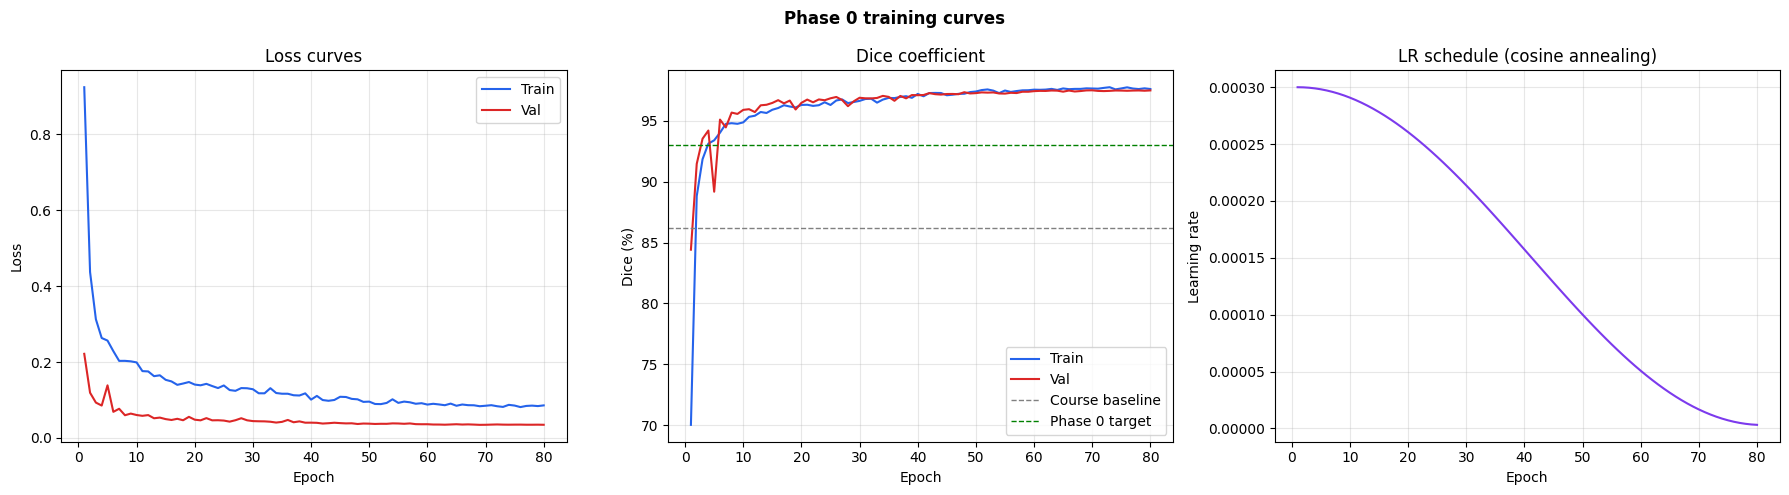

In [22]:
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(x, history['train_loss'], label='Train', color='#2563eb')
axes[0].plot(x, history['val_loss'],   label='Val',   color='#dc2626')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss curves'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(x, [d*100 for d in history['train_dice']], label='Train', color='#2563eb')
axes[1].plot(x, [d*100 for d in history['val_dice']],   label='Val',   color='#dc2626')
axes[1].axhline(86.17, color='gray', linestyle='--', linewidth=1, label='Course baseline')
axes[1].axhline(93.0,  color='green', linestyle='--', linewidth=1, label='Phase 0 target')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice (%)')
axes[1].set_title('Dice coefficient'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(x, history['lr'], color='#7c3aed')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning rate')
axes[2].set_title('LR schedule (cosine annealing)'); axes[2].grid(alpha=0.3)

plt.suptitle('Phase 0 training curves', fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Final evaluation on held-out test set

In [23]:
from scipy.optimize import minimize
from skimage.measure import label, regionprops


def fit_ellipse_to_mask(mask_bin):
    """
    Fit an ellipse to the largest connected component in a binary mask.
    Returns semi-axes (a, b) in pixels, or None if no valid region found.
    """
    labeled = label(mask_bin)
    if labeled.max() == 0:
        return None
    regions = regionprops(labeled)
    largest = max(regions, key=lambda r: r.area)

    # skimage regionprops gives major_axis_length and minor_axis_length
    a = largest.major_axis_length / 2
    b = largest.minor_axis_length / 2
    return a, b


def predict_hc_mm(model, img_tensor, pixel_spacing_mm, threshold=0.5):
    """
    Full inference pipeline: image → predicted HC in mm.

    Steps:
    1. Forward pass → probability mask
    2. Threshold to binary
    3. Fit ellipse to largest connected component
    4. HC = π × (a + b) using ellipse perimeter approximation
    5. Convert pixels → mm using pixel spacing

    Args:
        model: trained ResidualUNetDS in eval mode
        img_tensor: [1, 1, H, W] float tensor
        pixel_spacing_mm: mm per pixel (from HC18 metadata CSV)
        threshold: binarisation threshold

    Returns:
        hc_mm: float, or None if segmentation failed
    """
    model.eval()
    with torch.no_grad():
        pred = model(img_tensor.to(DEVICE)).cpu().squeeze().numpy()

    # Resize prediction back to original image size if needed
    # (here we work in the resized space — pixel_spacing must be adjusted accordingly)
    mask_bin = (pred > threshold).astype(np.uint8)

    result = fit_ellipse_to_mask(mask_bin)
    if result is None:
        return None

    a, b = result  # semi-axes in pixels (at INPUT resolution)

    # Ramanujan approximation for ellipse perimeter (more accurate than π(a+b))
    h = ((a - b) / (a + b)) ** 2
    hc_pixels = np.pi * (a + b) * (1 + (3 * h) / (10 + np.sqrt(4 - 3 * h)))

    # Scale pixel spacing for resized image
    # Original: 800x540 → resized: INPUT_W x INPUT_H
    # Pixel spacing scales inversely with image width
    scale_factor = 800 / INPUT_W  # assumes original width 800
    adjusted_spacing = pixel_spacing_mm * scale_factor

    hc_mm = hc_pixels * adjusted_spacing
    return hc_mm


print('Evaluation utilities defined.')

Evaluation utilities defined.


In [24]:
# Load best checkpoint
checkpoint = torch.load(BEST_CKPT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Loaded best checkpoint from epoch {checkpoint["epoch"]} '
      f'(val Dice: {checkpoint["val_dice"]*100:.2f}%)')

# Evaluate Dice and IoU on test set
model.eval()
test_dice_scores = []
test_iou_scores  = []

with torch.no_grad():
    for imgs, masks, stems in test_loader:
        imgs  = imgs.to(DEVICE)
        masks = masks.to(DEVICE)

        with torch.amp.autocast('cuda'):
            preds = model(imgs)

        preds_bin = (preds > 0.5).float()

        for i in range(len(imgs)):
            p = preds_bin[i].view(-1)
            t = masks[i].view(-1)
            smooth = 1e-5
            intersection = (p * t).sum()
            dice = (2 * intersection + smooth) / (p.sum() + t.sum() + smooth)
            iou  = (intersection + smooth) / (p.sum() + t.sum() - intersection + smooth)
            test_dice_scores.append(dice.item())
            test_iou_scores.append(iou.item())

mean_dice = np.mean(test_dice_scores) * 100
mean_iou  = np.mean(test_iou_scores)  * 100
print(f'\nTest set results:')
print(f'  Dice: {mean_dice:.2f}%  (course baseline: 86.17%  |  target: ≥93.0%)')
print(f'  IoU:  {mean_iou:.2f}%')

Loaded best checkpoint from epoch 70 (val Dice: 97.50%)

Test set results:
  Dice: 97.36%  (course baseline: 86.17%  |  target: ≥93.0%)
  IoU:  94.91%


In [25]:
# Compute HC MAE on test set using pixel spacing metadata
if PIXEL_CSV:
    df_meta = pd.read_csv(PIXEL_CSV)
    # Normalise column names — HC18 CSV has varying column name formats
    df_meta.columns = [c.strip().lower().replace(' ', '_') for c in df_meta.columns]
    print('Metadata columns:', df_meta.columns.tolist())
    print(df_meta.head(3))

    # Identify the pixel spacing column and HC ground truth column
    # Typical column names: 'pixel_size_in_mm', 'head_circumference_in_mm'
    # Adjust these if your CSV uses different names
    PIXEL_SIZE_COL = [c for c in df_meta.columns if 'pixel' in c][0]
    HC_GT_COL      = [c for c in df_meta.columns if 'head_circumference' in c or 'hc' in c.lower()][-1]
    print(f'\nUsing: pixel_size={PIXEL_SIZE_COL}, hc_gt={HC_GT_COL}')

    # Build a dict: stem → pixel_spacing
    # HC18 filenames in CSV are like '000_HC' or '000'
    filename_col = [c for c in df_meta.columns if 'filename' in c or 'file' in c][0]
    stem_to_spacing = {}
    stem_to_hc_gt   = {}
    for _, row in df_meta.iterrows():
        stem = str(row[filename_col]).replace('_HC.png', '').replace('.png', '')
        stem_to_spacing[stem] = float(row[PIXEL_SIZE_COL])
        stem_to_hc_gt[stem]   = float(row[HC_GT_COL])

    # Run HC prediction on test set
    hc_predictions = []
    hc_gt_values   = []

    for stem in test_stems:
        if stem not in stem_to_spacing:
            continue

        img_path = TRAIN_DIR / f'{stem}_HC.png'
        img_raw  = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

        aug     = val_transform(image=img_raw, mask=np.zeros_like(img_raw))
        img_t   = aug['image'].unsqueeze(0)  # [1, 1, H, W]

        hc_pred = predict_hc_mm(model, img_t, stem_to_spacing[stem])
        if hc_pred is not None:
            hc_predictions.append(hc_pred)
            hc_gt_values.append(stem_to_hc_gt[stem])

    errors = np.abs(np.array(hc_predictions) - np.array(hc_gt_values))
    mae    = np.mean(errors)
    rmse   = np.sqrt(np.mean(errors**2))
    r2     = 1 - np.sum(errors**2) / np.sum((np.array(hc_gt_values) - np.mean(hc_gt_values))**2)

    print(f'\nHC measurement results on {len(hc_predictions)} test images:')
    print(f'  MAE:  {mae:.2f} mm  (course baseline: 17.25 mm  |  target: ≤8 mm)')
    print(f'  RMSE: {rmse:.2f} mm')
    print(f'  R²:   {r2:.4f}')

Metadata columns: ['filename', 'pixel_size(mm)', 'head_circumference_(mm)']
     filename  pixel_size(mm)  head_circumference_(mm)
0  000_HC.png        0.069136                    44.30
1  001_HC.png        0.089659                    56.81
2  002_HC.png        0.062033                    68.75

Using: pixel_size=pixel_size(mm), hc_gt=head_circumference_(mm)

HC measurement results on 121 test images:
  MAE:  1.75 mm  (course baseline: 17.25 mm  |  target: ≤8 mm)
  RMSE: 2.43 mm
  R²:   0.9985


## 11. Qualitative results — prediction visualisation

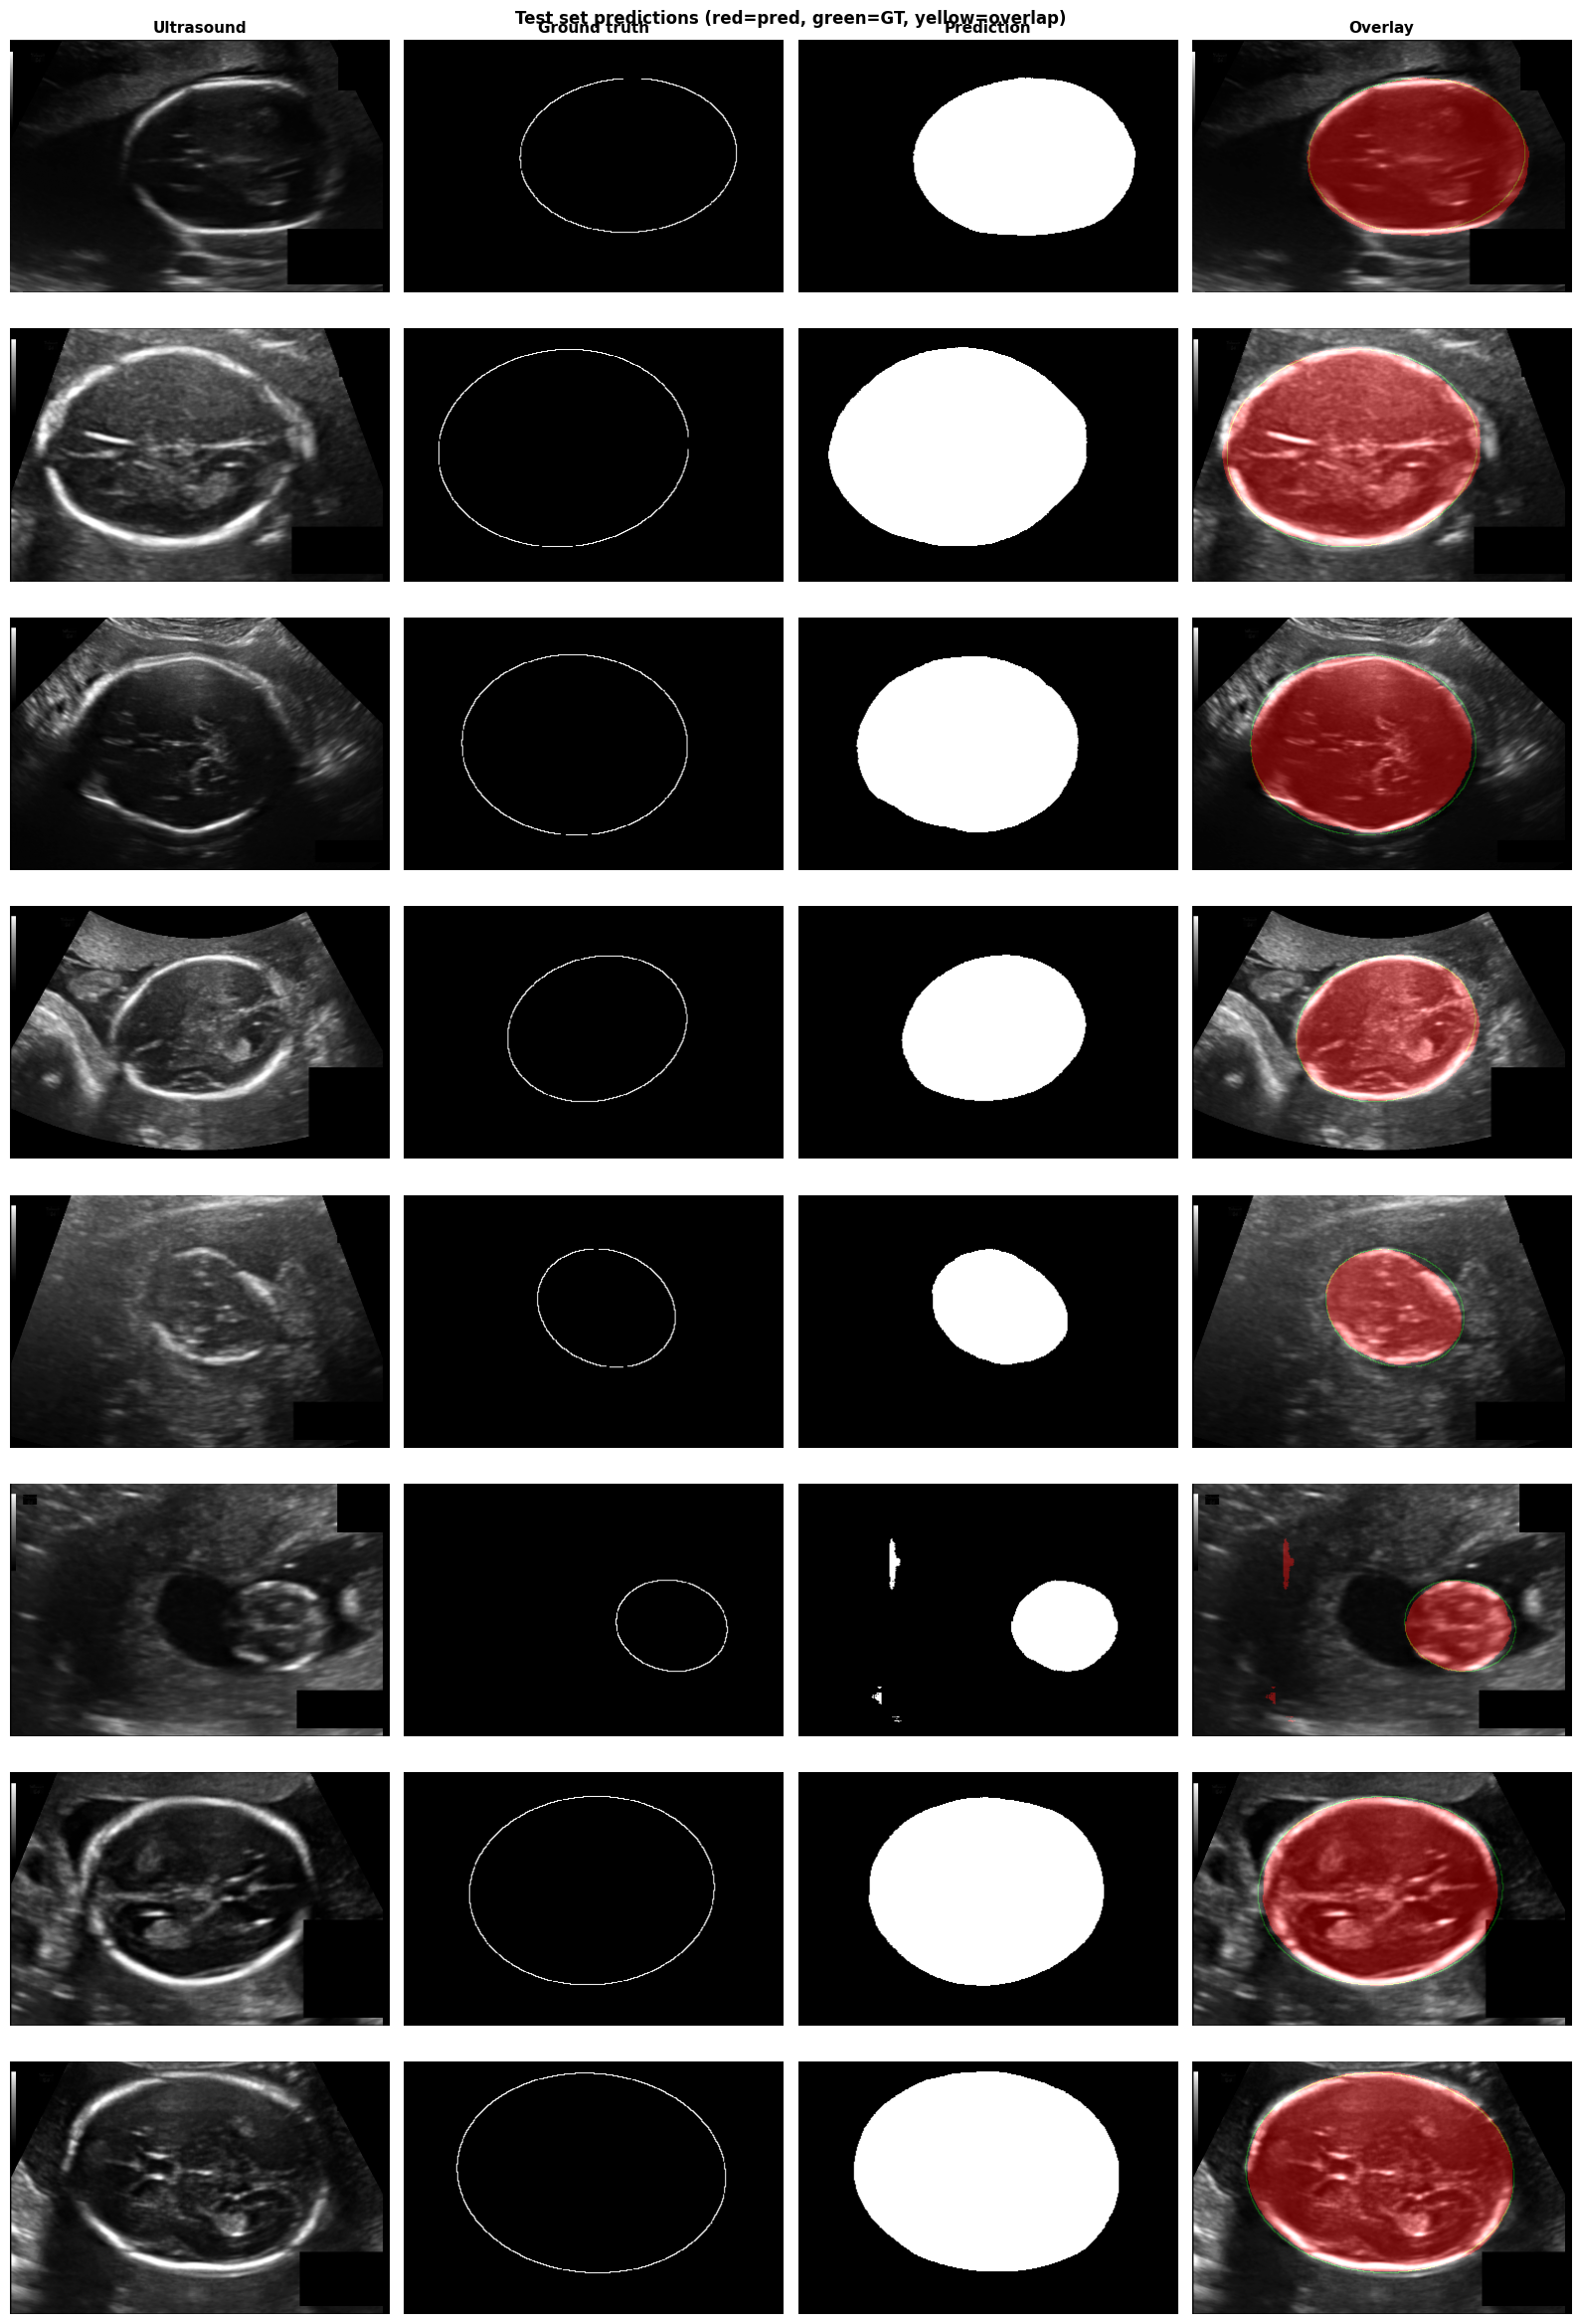

In [26]:
# Visual comparison: image | ground truth | prediction | overlay
model.eval()
n_show = 8
sample_stems = random.sample(test_stems, n_show)

fig, axes = plt.subplots(n_show, 4, figsize=(16, n_show * 3))
col_titles = ['Ultrasound', 'Ground truth', 'Prediction', 'Overlay']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontweight='bold', fontsize=11)

for row, stem in enumerate(sample_stems):
    img_raw  = cv2.imread(str(TRAIN_DIR / f'{stem}_HC.png'), cv2.IMREAD_GRAYSCALE)
    mask_raw = cv2.imread(str(TRAIN_DIR / f'{stem}_HC_Annotation.png'), cv2.IMREAD_GRAYSCALE)
    _, mask_bin = cv2.threshold(mask_raw, 127, 1, cv2.THRESH_BINARY)

    aug = val_transform(image=img_raw, mask=mask_bin.astype(np.uint8))
    img_t = aug['image'].unsqueeze(0)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            pred_prob = model(img_t.to(DEVICE)).cpu().squeeze().numpy()
    pred_bin = (pred_prob > 0.5).astype(np.uint8)
    gt_resized = aug['mask'].numpy()
    img_resized = aug['image'].squeeze().numpy()

    # Compute per-image dice for labelling
    smooth = 1e-5
    inter  = (pred_bin * gt_resized).sum()
    dice_i = (2 * inter + smooth) / (pred_bin.sum() + gt_resized.sum() + smooth)

    # Overlay
    overlay = np.stack([img_resized]*3, axis=-1)
    overlay = (overlay - overlay.min()) / (overlay.max() - overlay.min())
    overlay[pred_bin > 0, 0] = np.clip(overlay[pred_bin > 0, 0] + 0.4, 0, 1)  # red channel
    overlay[gt_resized > 0, 1] = np.clip(overlay[gt_resized > 0, 1] + 0.3, 0, 1)  # green

    axes[row, 0].imshow(img_resized, cmap='gray'); axes[row, 0].axis('off')
    axes[row, 1].imshow(gt_resized,  cmap='gray'); axes[row, 1].axis('off')
    axes[row, 2].imshow(pred_bin,    cmap='gray')
    axes[row, 2].set_xlabel(f'Dice: {dice_i*100:.1f}%', fontsize=9)
    axes[row, 2].axis('off')
    axes[row, 3].imshow(overlay)     ; axes[row, 3].axis('off')

plt.suptitle('Test set predictions (red=pred, green=GT, yellow=overlap)', fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'test_predictions.png'), dpi=130, bbox_inches='tight')
plt.show()

## 12. Save final results summary

In [27]:
# Compile results for comparison with course baseline and Phase 2 later
results_summary = {
    'phase': 'Phase 0 — Baseline repair',
    'model': 'ResidualUNetDS (base_ch=32)',
    'improvements': [
        'Strong augmentation (rotation, flip, elastic, brightness, noise, dropout)',
        'Deep supervision (auxiliary heads at decoder stages 2 and 3)',
        'Boundary-weighted BCE+Dice loss',
        'AdamW + cosine annealing LR schedule',
        'Mixed precision training'
    ],
    'test_dice_pct':   round(mean_dice, 2),
    'test_iou_pct':    round(mean_iou, 2),
    'hc_mae_mm':       round(float(mae), 2)  if PIXEL_CSV else 'N/A',
    'hc_rmse_mm':      round(float(rmse), 2) if PIXEL_CSV else 'N/A',
    'hc_r2':           round(float(r2), 4)   if PIXEL_CSV else 'N/A',
    'baseline_dice_pct':  86.17,
    'baseline_mae_mm':    17.25,
    'best_checkpoint':    BEST_CKPT_PATH,
    'notes': (
        'This backbone will be frozen and used as the 2D encoder '
        'in Phase 2 (temporal attention cine-loop system).'
    )
}

with open(str(RESULTS_DIR / 'phase0_results.json'), 'w') as f:
    json.dump(results_summary, f, indent=2)

print('Results saved to Drive.')
print('\n=== PHASE 0 SUMMARY ===')
print(f'Dice:  {mean_dice:.2f}%  (was 86.17%,  target ≥93%)')
if PIXEL_CSV:
    print(f'MAE:   {mae:.2f} mm  (was 17.25mm, target ≤8mm)')
print(f'\nBackbone checkpoint saved to: {BEST_CKPT_PATH}')
print('Ready for Phase 1 — Pseudo-LDDM v2 cine generation.')

Results saved to Drive.

=== PHASE 0 SUMMARY ===
Dice:  97.36%  (was 86.17%,  target ≥93%)
MAE:   1.75 mm  (was 17.25mm, target ≤8mm)

Backbone checkpoint saved to: /content/drive/MyDrive/fetal_head_clinical_ai/checkpoints/phase0/best_model.pth
Ready for Phase 1 — Pseudo-LDDM v2 cine generation.


In [28]:
print("=== PHASE 0 HANDOFF ===")
print(f"Backbone checkpoint: {BEST_CKPT_PATH}")
print(f"Model config: ResidualUNetDS, in_ch=1, base_ch=32")
print(f"Input size: {INPUT_H} x {INPUT_W}")
print(f"Test Dice: 97.36% | IoU: 94.91% | MAE: 1.75mm | RMSE: 2.43mm | R²: 0.9985")
print(f"Data split JSON: {str(RESULTS_DIR / 'data_split.json')}")
print(f"image_mask_pairs length: {len(image_mask_pairs)}")
print(f"TRAIN_DIR: {TRAIN_DIR}")
print(f"PIXEL_CSV: {PIXEL_CSV}")

=== PHASE 0 HANDOFF ===
Backbone checkpoint: /content/drive/MyDrive/fetal_head_clinical_ai/checkpoints/phase0/best_model.pth
Model config: ResidualUNetDS, in_ch=1, base_ch=32
Input size: 256 x 384
Test Dice: 97.36% | IoU: 94.91% | MAE: 1.75mm | RMSE: 2.43mm | R²: 0.9985
Data split JSON: /content/drive/MyDrive/fetal_head_clinical_ai/results/phase0/data_split.json
image_mask_pairs length: 999
TRAIN_DIR: /content/hc18/archive (4)/training_set/training_set
PIXEL_CSV: /content/hc18/archive (4)/training_set_pixel_size_and_HC.csv
